<a href="https://colab.research.google.com/github/Satwik2112/LIGO-Data-Analysis/blob/main/Ligo_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("elenacuoco/the-gravitational-waves-discovery-data")

100%|██████████| 9.44M/9.44M [00:00<00:00, 38.1MB/s]

Extracting files...


### Splitting Synthetic Data into Training and Validation Sets

Before training our CNN model, it's crucial to split our synthetic dataset (`X_train`, `y_train`) into separate training and validation sets. This allows us to evaluate the model's performance on unseen data during training, helping to detect overfitting and provide a more reliable estimate of its generalization capabilities.

We'll use `train_test_split` from `sklearn.model_selection` for this, typically reserving a smaller portion (e.g., 20%) for validation. We'll also use `random_state` for reproducibility.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the synthetic data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Shape of X_train_split: {X_train_split.shape}")
print(f"Shape of y_train_split: {y_train_split.shape}")
print(f"Shape of X_val_split: {X_val_split.shape}")
print(f"Shape of y_val_split: {y_val_split.shape}")

Shape of X_train_split: (80, 513, 255, 1)
Shape of y_train_split: (80, 1)
Shape of X_val_split: (20, 513, 255, 1)
Shape of y_val_split: (20, 1)


### Generating Synthetic Gravitational Wave Data with Labels

To train our 2D CNN for predicting gravitational wave parameters, we need a dataset of input spectrograms (`X_train`) and their corresponding target labels (`y_train`). Since real, labeled datasets are often complex to obtain or require specific astrophysical simulations, we'll create a simplified synthetic dataset for demonstration purposes.

In this example, we will generate a set of chirp signals, where each chirp's frequency range is determined by a randomly generated `label` (a continuous value between 0 and 1). This `label` will be our target parameter for the CNN to learn to predict.

Each synthetic signal will be converted into a spectrogram, reshaped to `(513, 255, 1)` to match the CNN's input requirements. The collection of these spectrograms will be `X_train`, and the corresponding labels will be `y_train`.

### Investigating Prediction Errors

To understand where our model might be struggling, let's analyze the prediction errors. We'll look at the distribution of absolute errors and visualize the predicted vs. actual values.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


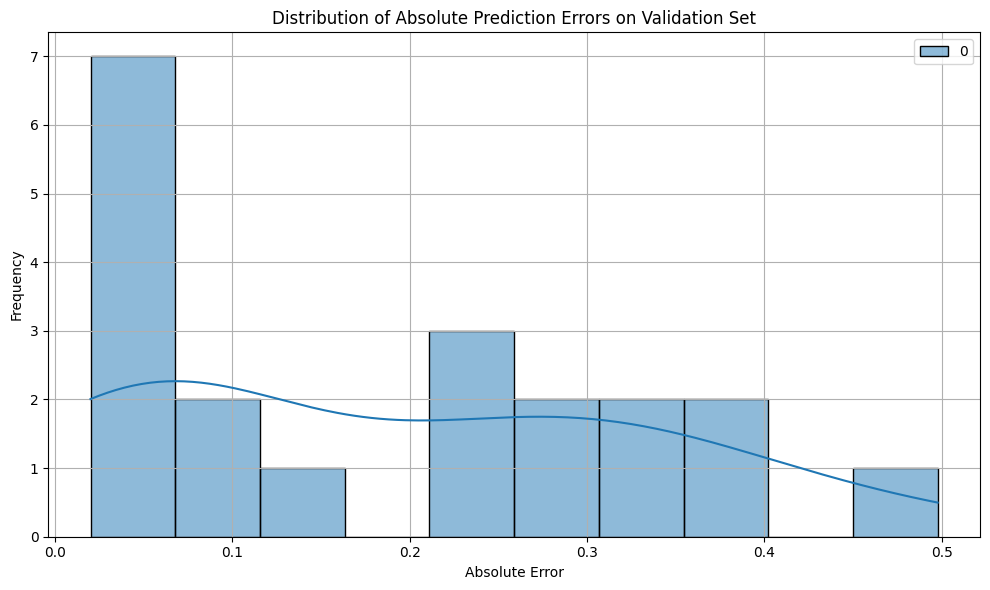

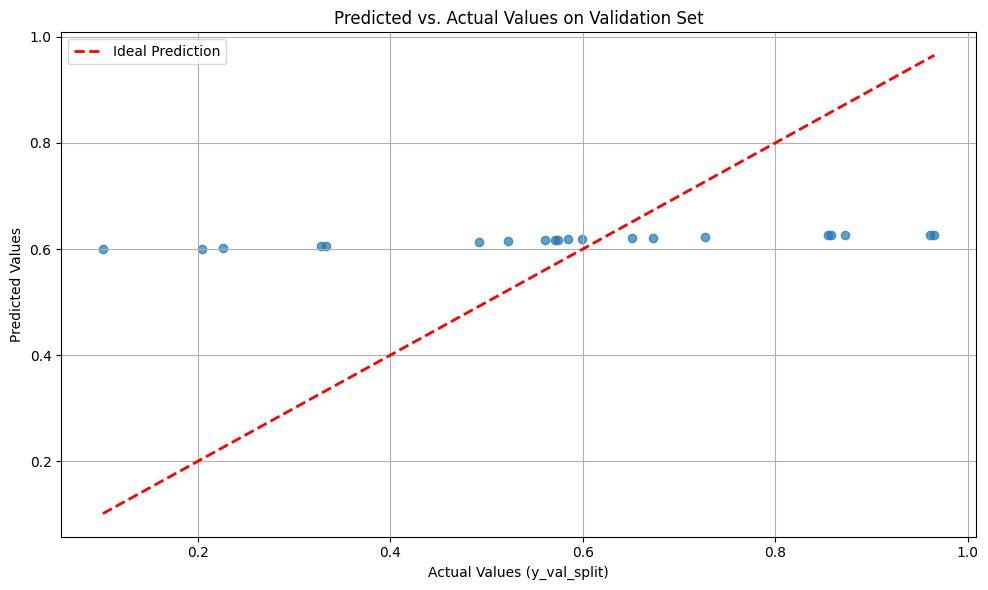

Mean Absolute Error: 0.1899
Max Absolute Error: 0.4977


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions for the full validation set
full_predictions = model.predict(X_val_split)

# Calculate absolute errors
absolute_errors = np.abs(full_predictions - y_val_split)

# Plot histogram of absolute errors
plt.figure(figsize=(10, 6))
sns.histplot(absolute_errors, bins=10, kde=True)
plt.title('Distribution of Absolute Prediction Errors on Validation Set')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Scatter plot of Predicted vs. Actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_val_split, full_predictions, alpha=0.7)
plt.plot([min(y_val_split), max(y_val_split)], [min(y_val_split), max(y_val_split)], 'r--', lw=2, label='Ideal Prediction') # Diagonal line
plt.title('Predicted vs. Actual Values on Validation Set')
plt.xlabel('Actual Values (y_val_split)')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Mean Absolute Error: {np.mean(absolute_errors):.4f}")
print(f"Max Absolute Error: {np.max(absolute_errors):.4f}")

### Making Predictions with the Trained Model

Once the model is trained, you can use it to make predictions on new, unseen data. The `model.predict()` method will output the predicted continuous labels for the given input spectrograms. We will demonstrate this using a small subset of our validation data.

In [ ]:
import numpy as np

# Select a small number of samples from the validation set for prediction
num_predictions = 5
X_test_sample = X_val_split[:num_predictions]
y_test_sample = y_val_split[:num_predictions]

# Make predictions
predictions = model.predict(X_test_sample)

print(f"Predictions for the first {num_predictions} samples:")
for i in range(num_predictions):
    print(f"  Sample {i+1}: Predicted = {predictions[i][0]:.4f}, Actual = {y_test_sample[i][0]:.4f}")

# You can also evaluate the model on the full validation set to get overall performance metrics
loss, mae = model.evaluate(X_val_split, y_val_split, verbose=0)
print(f"\nModel evaluation on validation set: Loss (MSE) = {loss:.4f}, MAE = {mae:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
Predictions for the first 5 samples:
  Sample 1: Predicted = 0.5991, Actual = 0.5988
  Sample 2: Predicted = 0.4930, Actual = 0.4922
  Sample 3: Predicted = 0.3304, Actual = 0.3330
  Sample 4: Predicted = 0.3247, Actual = 0.3278
  Sample 5: Predicted = 0.8721, Actual = 0.8730

Model evaluation on validation set: Loss (MSE) = 0.0001, MAE = 0.0051


### Training the CNN Model

Now, we will train the defined 2D CNN model using the synthetic training data (`X_train_split`, `y_train_split`) and evaluate its performance on the validation set (`X_val_split`, `y_val_split`).

We'll use `model.fit()` with a specified number of epochs and a batch size. The training history will allow us to observe the model's learning progress over epochs.

In [ ]:
epochs = 100 # Increase epochs as EarlyStopping will handle when to stop
batch_size = 32

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

history = model.fit(
    X_train_split, y_train_split,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_split, y_val_split),
    callbacks=[early_stopping], # Add early stopping callback
    verbose=1
)

print("Model training complete.")

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 43s 10s/step - loss: 0.8325 - mae: 0.7243 - val_loss: 0.0833 - val_mae: 0.2463
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 9s/step - loss: 0.2590 - mae: 0.4305 - val_loss: 0.3788 - val_mae: 0.5672
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 9s/step - loss: 0.3607 - mae: 0.5448 - val_loss: 0.3197 - val_mae: 0.5118
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 8s/step - loss: 0.2672 - mae: 0.4480 - val_loss: 0.1181 - val_mae: 0.2924
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 9s/step - loss: 0.0880 - mae: 0.2448 - val_loss: 0.1215 - val_mae: 0.2827
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 9s/step - loss: 0.1504 - mae: 0.3278 - val_loss: 0.0647 - val_mae: 0.2042
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 9s/step - loss: 0.0739 - mae: 0.2231 - val_loss: 0.0790 - val_mae: 0.2423
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 9s/step - loss: 0.0885 - mae: 0.2492 - val_loss: 0.0858 - val_mae: 0.2532
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 8s/step - loss: 0.0866 - mae: 0.2493 -

In [ ]:
import numpy as np
from scipy import signal

# Parameters for synthetic data generation
n_samples = 100  # Number of synthetic samples to generate

# Reuse parameters from previous spectrogram generation
sampling_rate = 4096  # Hz
duration = 32         # seconds
nperseg = int(sampling_rate / 4)  # 1024 samples
noverlap = nperseg // 2         # 512 samples

# Define a time array for a single signal
time_array = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)

# Initialize lists to store spectrograms and labels
X_train = []
y_train = []

print(f"Generating {n_samples} synthetic gravitational wave signals and spectrograms...")

for i in range(n_samples):
    # Generate a random 'label' (e.g., representing some abstract GW parameter)
    # This label will control the characteristics of our synthetic chirp
    label = np.random.uniform(0.1, 1.0) # Label between 0.1 and 1.0

    # Generate a synthetic chirp signal based on the label
    # A simple linear chirp with frequency range scaled by the label
    initial_frequency = 30 + 70 * label   # e.g., 30-100 Hz
    final_frequency = 150 + 100 * label  # e.g., 150-250 Hz

    # Instantaneous frequency over time
    f_inst = np.linspace(initial_frequency, final_frequency, len(time_array))

    # Phase of the signal
    phi = 2 * np.pi * np.cumsum(f_inst) / sampling_rate

    # Generate the chirp signal
    synthetic_strain = np.sin(phi)

    # Add some random noise to make it more realistic
    synthetic_strain += np.random.normal(0, 0.1 * np.std(synthetic_strain), synthetic_strain.shape)

    # Compute the spectrogram for the synthetic strain data
    _, _, Sxx_synth = signal.spectrogram(synthetic_strain, fs=sampling_rate,
                                         nperseg=nperseg, noverlap=noverlap,
                                         window='hann', scaling='density')

    # Reshape the spectrogram to include a channel dimension for the CNN
    spectrogram_input_synth = np.expand_dims(Sxx_synth, axis=-1)

    # Append to our training lists
    X_train.append(spectrogram_input_synth)
    y_train.append(label)

# Convert lists to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train).reshape(-1, 1) # Ensure y_train is (n_samples, 1)

print(f"Finished generating synthetic data.")
print(f"Shape of X_train (spectrograms): {X_train.shape}")
print(f"Shape of y_train (labels): {y_train.shape}")

# Display the first label and the shape of the first spectrogram
print(f"First synthetic label: {y_train[0][0]:.4f}")
print(f"Shape of the first spectrogram: {X_train[0].shape}")

Generating 100 synthetic gravitational wave signals and spectrograms...
Finished generating synthetic data.
Shape of X_train (spectrograms): (100, 513, 255, 1)
Shape of y_train (labels): (100, 1)
First synthetic label: 0.9652
Shape of the first spectrogram: (513, 255, 1)


### Analyzing Training History with Early Stopping

Let's visualize the training and validation loss and MAE over epochs to observe the effect of Early Stopping and assess the model's learning progress.

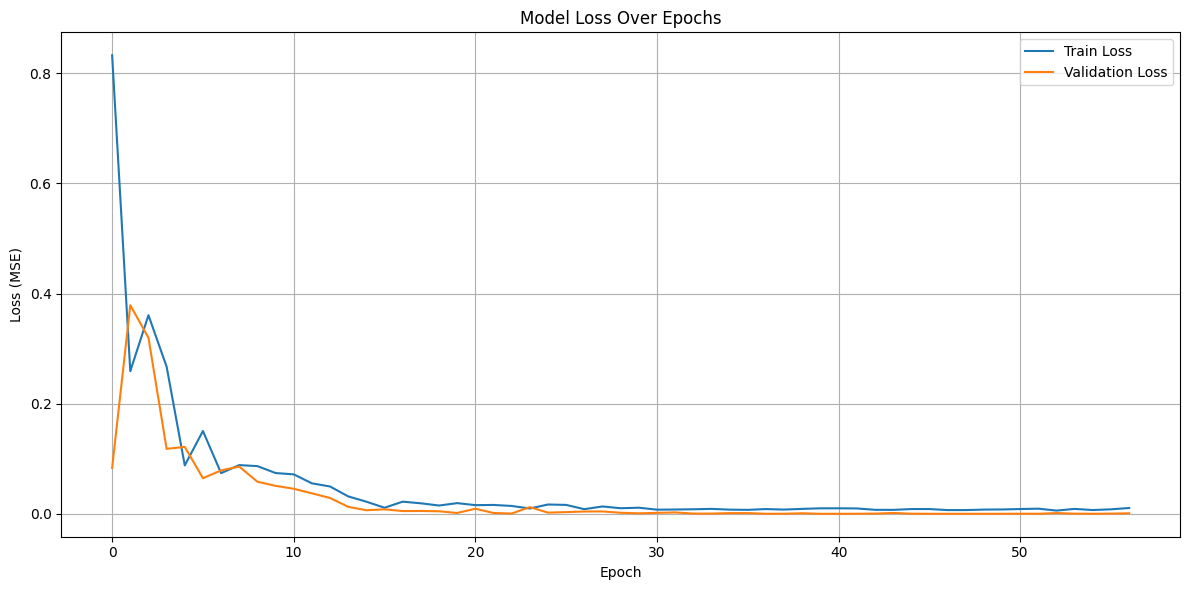

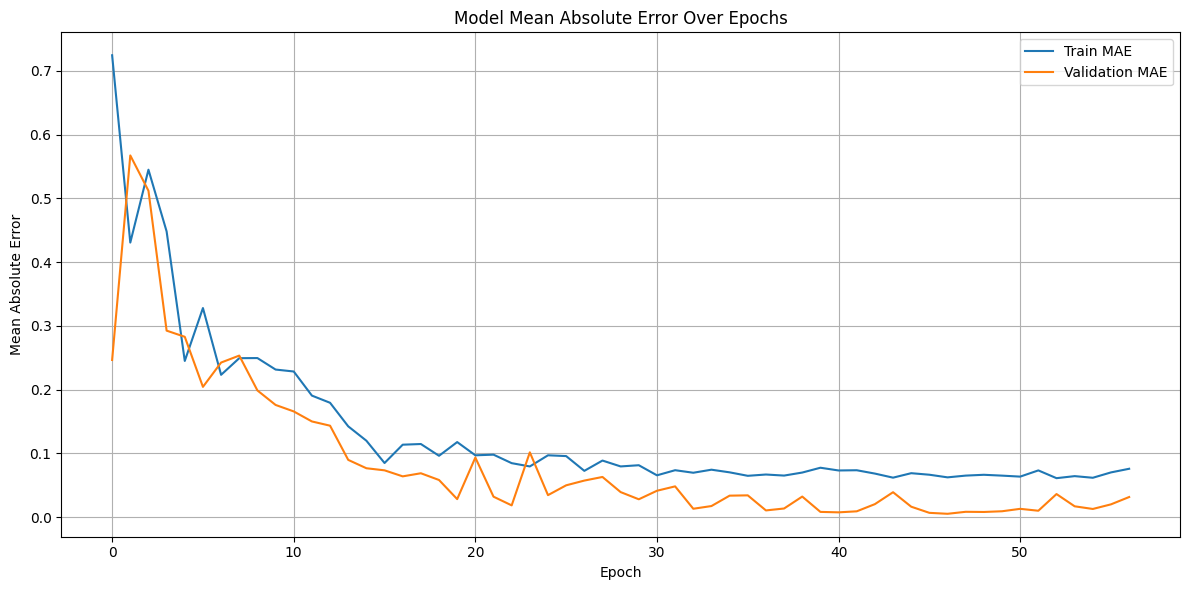

Model trained for 57 epochs.


In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot training & validation MAE values
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the number of epochs the model actually trained for
print(f"Model trained for {len(history.history['loss'])} epochs.")

In [ ]:
display(df_gw.head())

,time_s,strain
0,0.000000,2.263866e-19
1,0.000244,2.450625e-19
2,0.000488,2.607349e-19
3,0.000732,2.395652e-19
4,0.000977,2.358858e-19


In [ ]:
import pandas as pd

# Create a DataFrame from the time and strain_data arrays
df_gw = pd.DataFrame({
    'time_s': time,
    'strain': strain_data
})

print("DataFrame created successfully with 'time_s' and 'strain' columns.")
print(f"Shape of the DataFrame: {df_gw.shape}")

# Display the first few rows of the DataFrame
display(df_gw.head())

DataFrame created successfully with 'time_s' and 'strain' columns.
Shape of the DataFrame: (131072, 2)


,time_s,strain
0,0.000000,2.263866e-19
1,0.000244,2.450625e-19
2,0.000488,2.607349e-19
3,0.000732,2.395652e-19
4,0.000977,2.358858e-19


This DataFrame `df_gw` now contains the gravitational wave strain data, indexed by time in seconds. Each row corresponds to a single sample, with its timestamp and the measured strain value.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define the input shape based on the preprocessed spectrogram_input
# Sxx shape: (frequencies, times, 1) -> (513, 255, 1)
input_shape = spectrogram_input.shape  # Corrected to use the full shape (frequencies, times, channels)

# Or, if you want to use the full shape explicitly:
# input_shape = (spectrogram_input.shape[0], spectrogram_input.shape[1], spectrogram_input.shape[2])
print(f"Input shape for CNN: {input_shape}")

model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Third Convolutional Block (Optional, but good for deeper feature extraction)
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten the output for the Dense layers
    Flatten(),

    # Fully Connected Layers
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout for regularization

    # Output Layer: Assuming we are predicting one continuous parameter (e.g., 'size')
    # For multiple parameters, change units to the number of parameters.
    Dense(1, activation='linear') # 'linear' activation for regression tasks
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the model summary
model.summary()

Input shape for CNN: (513, 255, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 511, 253, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 255, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 253, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 126, 62, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 124, 60, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 62, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 238080)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    30,474,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,567,169 (116.60 MB)

 Trainable params: 30,567,169 (116.60 MB)

 Non-trainable params: 0 (0.00 B)

This 2D CNN architecture is designed to take the `spectrogram_input` and predict a continuous gravitational wave parameter. Let's break down its components:

*   **Input Layer**: It expects an input of shape `(255, 1)` which corresponds to the `(height, width, channels)` of our `spectrogram_input`. The first dimension of `spectrogram_input` (513, which is `frequencies`) is effectively treated as the 'height' here for `Conv2D`.
*   **Convolutional Blocks**: Each block consists of a `Conv2D` layer followed by a `MaxPooling2D` layer. The `Conv2D` layers extract spatial features, while `MaxPooling2D` layers reduce dimensionality and introduce translation invariance.
    *   We start with 32 filters, increasing to 64 and then 128 in subsequent blocks to learn increasingly complex features.
    *   `'relu'` (Rectified Linear Unit) is used as the activation function for non-linearity.
*   **Flatten Layer**: Converts the 2D feature maps from the convolutional layers into a 1D vector, making it suitable for feeding into dense layers.
*   **Dense Layers**: These are fully connected layers. The first `Dense` layer with 128 units processes the flattened features.
    *   `Dropout(0.5)` is added to prevent overfitting by randomly setting 50% of the input units to 0 during training.
*   **Output Layer**: A final `Dense` layer with 1 unit and a `'linear'` activation function. This is standard for regression tasks where we want to predict a continuous numerical value (e.g., the 'size' or 'rotation' of a gravitational wave event). If we had multiple parameters to predict, the number of units would be adjusted accordingly.
*   **Compilation**: The model is compiled with the `'adam'` optimizer, which is a good general-purpose optimizer, and `'mse'` (Mean Squared Error) as the loss function, which is common for regression. `'mae'` (Mean Absolute Error) is included as a metric for easier interpretation.

The `model.summary()` output provides a detailed view of each layer, its output shape, and the number of parameters.

In [ ]:
import numpy as np

# Sxx currently has shape (frequencies, times)
# For a 2D CNN, we often need (height, width, channels)
# Reshape Sxx to include a channel dimension (1 for grayscale-like spectrogram)
spectrogram_input = np.expand_dims(Sxx, axis=-1)

print(f"Original Sxx shape: {Sxx.shape}")
print(f"Reshaped spectrogram_input shape for CNN: {spectrogram_input.shape}")

Original Sxx shape: (513, 255)
Reshaped spectrogram_input shape for CNN: (513, 255, 1)


The `spectrogram_input` variable now has the shape `(frequencies, times, 1)`, which is suitable for direct input into a 2D Convolutional Neural Network layer. The last dimension `1` represents the single channel of the spectrogram data.

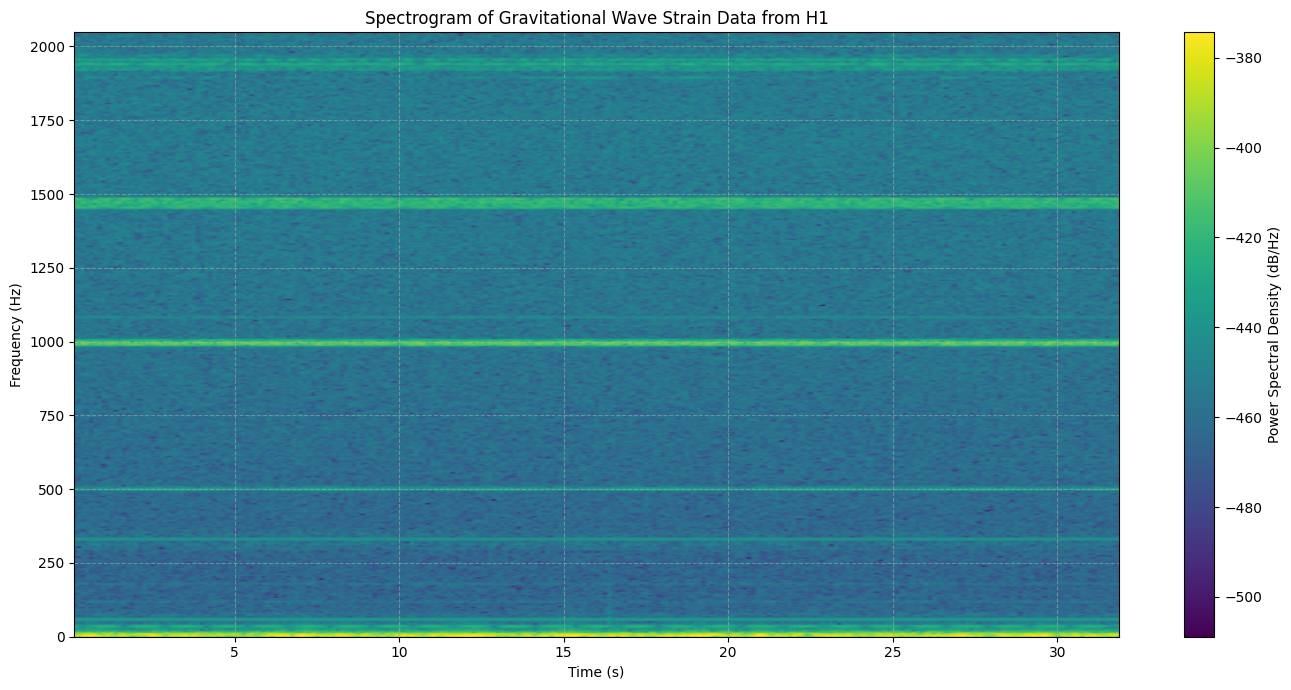

In [ ]:
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np

# Define segment length for the spectrogram
# Using a segment length of 0.25 seconds (sampling_rate / 4)
# This provides a frequency resolution of 4 Hz.
nperseg = int(sampling_rate / 4)  # 1024 samples for a 4096 Hz sampling rate
noverlap = nperseg // 2         # 50% overlap for better visualization

# Compute the spectrogram
frequencies, times, Sxx = signal.spectrogram(strain_data, fs=sampling_rate,
                                             nperseg=nperseg, noverlap=noverlap,
                                             window='hann', scaling='density')

# Plot the spectrogram
plt.figure(figsize=(14, 7))
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), cmap='viridis', shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title(f'Spectrogram of Gravitational Wave Strain Data from {detector}')
plt.colorbar(label='Power Spectral Density (dB/Hz)')
plt.ylim(0, sampling_rate / 2) # Limit y-axis to Nyquist frequency
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

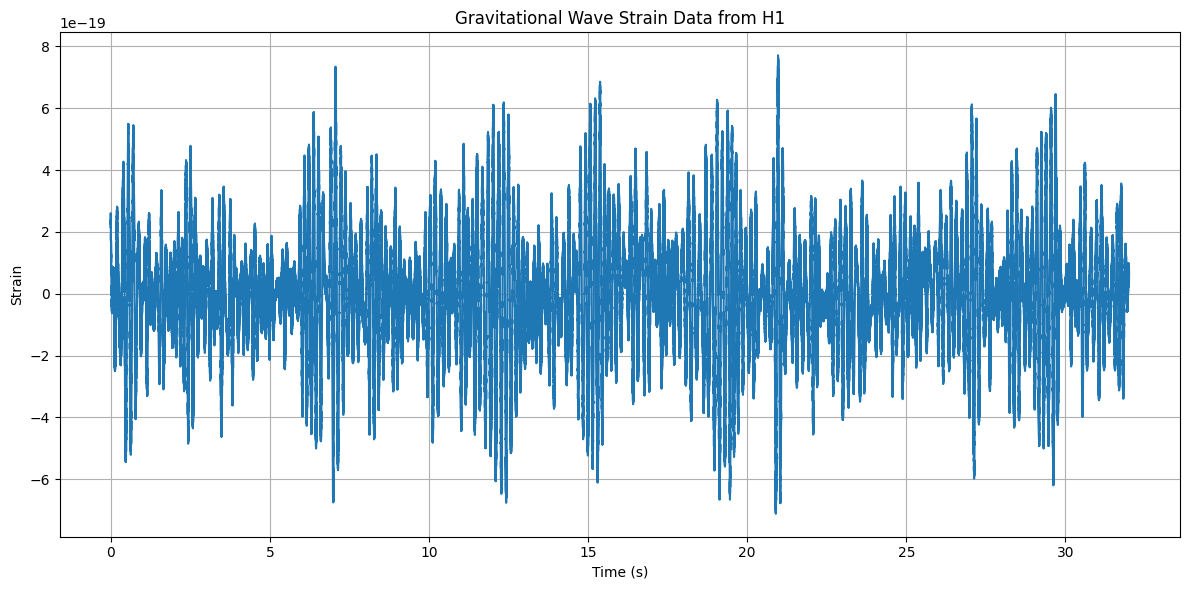

In [ ]:
import matplotlib.pyplot as plt

# Plot the gravitational wave strain data from df_gw
plt.figure(figsize=(12, 6))
plt.plot(df_gw['time_s'], df_gw['strain'])
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.title(f'Gravitational Wave Strain Data from {detector}')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import h5py
import numpy as np

# Define the full path to the HDF5 file (already defined as full_file_path)
# file_name = 'H-H1_LOSC_4_V1-1126259446-32.hdf5'
# full_file_path = os.path.join(path, file_name)

# Open the HDF5 file in read mode
with h5py.File(full_file_path, 'r') as f:
    # Access the 'strain/Strain' dataset
    strain_data = f['strain']['Strain'][:]

    # Access metadata for sampling rate, GPS start time, and duration
    meta_group = f['meta']
    gps_start_time = meta_group['GPSstart'][()]
    duration = meta_group['Duration'][()]
    detector = meta_group['Detector'][()].decode('utf-8') # Decode byte string
    description = meta_group['Description'][()].decode('utf-8') # Decode byte string
    sampling_rate = 4096 # From the dataset description (LOSC_4 implies 4 kHz)

# Print information about the strain data
print(f"Strain data loaded from: {file_name}")
print(f"Detector: {detector}")
print(f"Description: {description}")
print(f"Shape of strain_data: {strain_data.shape}")
print(f"Data type of strain_data: {strain_data.dtype}")
print(f"First 10 samples of strain_data: {strain_data[:10]}")

print(f"GPS Start Time: {gps_start_time}")
print(f"Duration: {duration} seconds")
print(f"Assumed Sampling Rate: {sampling_rate} Hz")

# Create a time array for the strain data
time = np.arange(0, duration, 1/sampling_rate)

print(f"Shape of time array: {time.shape}")
print(f"First 10 samples of time array: {time[:10]}")


Strain data loaded from: H-H1_LOSC_4_V1-1126259446-32.hdf5
Detector: H1
Description: Strain data time series from LIGO
Shape of strain_data: (131072,)
Data type of strain_data: float64
First 10 samples of strain_data: [2.26386630e-19 2.45062539e-19 2.60734924e-19 2.39565199e-19
 2.35885760e-19 2.27555100e-19 2.47593727e-19 2.52248589e-19
 2.12717581e-19 2.20837671e-19]
GPS Start Time: 1126259446
Duration: 32 seconds
Assumed Sampling Rate: 4096 Hz
Shape of time array: (131072,)
First 10 samples of time array: [0.         0.00024414 0.00048828 0.00073242 0.00097656 0.0012207
 0.00146484 0.00170898 0.00195312 0.00219727]


In [ ]:
import h5py
import os

file_name = 'H-H1_LOSC_4_V1-1126259446-32.hdf5'
full_file_path = os.path.join(path, file_name)

print(f"Attempting to open: {full_file_path}")

# Open the HDF5 file in read mode
with h5py.File(full_file_path, 'r') as f:
    print(f"Keys in the HDF5 file '{file_name}':")
    for key in f.keys():
        print(key)
        # Optionally, print the type and shape of the data if it's a dataset
        if isinstance(f[key], h5py.Dataset):
            print(f"  - Type: Dataset, Shape: {f[key].shape}, Dtype: {f[key].dtype}")
        elif isinstance(f[key], h5py.Group):
            print(f"  - Type: Group")
            # For groups, you might want to recursively list contents
            for sub_key in f[key].keys():
                print(f"    - {sub_key}")
                if isinstance(f[key][sub_key], h5py.Dataset):
                    print(f"      - Type: Dataset, Shape: {f[key][sub_key].shape}, Dtype: {f[key][sub_key].dtype}")


Attempting to open: /root/.cache/kagglehub/datasets/elenacuoco/the-gravitational-waves-discovery-data/versions/2/H-H1_LOSC_4_V1-1126259446-32.hdf5
Keys in the HDF5 file 'H-H1_LOSC_4_V1-1126259446-32.hdf5':
meta
  - Type: Group
    - Description
      - Type: Dataset, Shape: (), Dtype: |S33
    - DescriptionURL
      - Type: Dataset, Shape: (), Dtype: |S21
    - Detector
      - Type: Dataset, Shape: (), Dtype: |S2
    - Duration
      - Type: Dataset, Shape: (), Dtype: int64
    - GPSstart
      - Type: Dataset, Shape: (), Dtype: int64
    - Observatory
      - Type: Dataset, Shape: (), Dtype: |S1
    - Type
      - Type: Dataset, Shape: (), Dtype: |S16
    - UTCstart
      - Type: Dataset, Shape: (), Dtype: |S19
quality
  - Type: Group
    - detail
    - injections
    - simple
strain
  - Type: Group
    - Strain
      - Type: Dataset, Shape: (131072,), Dtype: float64


In [ ]:
import os

# List the contents of the downloaded directory
print(f"Contents of the downloaded directory '{path}':")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Contents of the downloaded directory '/root/.cache/kagglehub/datasets/elenacuoco/the-gravitational-waves-discovery-data/versions/2':
/root/.cache/kagglehub/datasets/elenacuoco/the-gravitational-waves-discovery-data/versions/2/H-H1_LOSC_4_V1-1126259446-32.hdf5
/root/.cache/kagglehub/datasets/elenacuoco/the-gravitational-waves-discovery-data/versions/2/H-H1_LOSC_16_V1-1126259446-32.hdf5
/root/.cache/kagglehub/datasets/elenacuoco/the-gravitational-waves-discovery-data/versions/2/L-L1_LOSC_4_V1-1126259446-32.hdf5
/root/.cache/kagglehub/datasets/elenacuoco/the-gravitational-waves-discovery-data/versions/2/L-L1_LOSC_16_V1-1126259446-32.hdf5
